# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Haseeb Hassan
**Student ID:** 023-24-0274
**Section:** H
**GitHub:** [Haseeb-Hassan66](https://github.com/Haseeb-Hassan66)
**Kaggle:** [haseebsamo66737](https://www.kaggle.com/haseebsamo66737)
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [3]:
# Task 1 — load spam.csv, inspect shape/head/class balance

spam_df = pd.read_csv('spam.csv', encoding='latin-1', usecols=['v1', 'v2'])
tweets_df = pd.read_csv('Tweets.csv')

print("Spam Dataset:")
print("Shape:", spam_df.shape)
print("Rows:", len(spam_df))
print(spam_df.head())

print("\nClass Balance:")
print(spam_df['v1'].value_counts())

print("\nClass Percentages:")
print((spam_df['v1'].value_counts(normalize=True) * 100).round(2))

print("\n" + "="*50)

print("\nTwitter Sentiment Dataset:")
print("Shape:", tweets_df.shape)
print("Rows:", len(tweets_df))
print(tweets_df.head())
print("\nClass Balance:")
print(tweets_df['airline_sentiment'].value_counts())
print("\nClass Percentages:")
print((tweets_df['airline_sentiment'].value_counts(normalize=True) * 100).round(2))


Spam Dataset:
Shape: (5572, 2)
Rows: 5572
     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class Balance:
v1
ham     4825
spam     747
Name: count, dtype: int64

Class Percentages:
v1
ham     86.59
spam    13.41
Name: proportion, dtype: float64


Twitter Sentiment Dataset:
Shape: (14640, 15)
Rows: 14640
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722   

In [4]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets_df = tweets_df[
    tweets_df['airline_sentiment'].isin(['positive', 'negative'])
].copy()

print("Rows after dropping neutral tweets:", len(tweets_df))

print("\nClass Balance:")
print(tweets_df['airline_sentiment'].value_counts())

print("\nClass Percentages:")
print((tweets_df['airline_sentiment'].value_counts(normalize=True)*100).round(2))

Rows after dropping neutral tweets: 11541

Class Balance:
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

Class Percentages:
airline_sentiment
negative    79.53
positive    20.47
Name: proportion, dtype: float64


**Answer 1 (dataset summary):**

**Task A: SMS Spam Collection.** It has 5,572 rows and each row is one SMS message with a label (ham or spam). There are 4,825 ham messages (86.59%) and 747 spam messages (13.41%), so the classes are imbalanced.

**Task B: Twitter US Airline Sentiment.** It has 14,640 rows and each row is one tweet about a US airline. The full label counts are negative 9,178 (62.69%), neutral 3,099 (21.17%) and positive 2,363 (16.14%). After dropping the neutral tweets I have 11,541 rows left: 9,178 negative (79.53%) and 2,363 positive (20.47%).

**Answer 2 (Task A — spam):**  
*The practical problem is to classify SMS messages as either spam or ham so that unwanted messages can be filtered automatically. It is a binary classification problem because there are only two possible classes: spam and ham.*

**Answer 2 (Task B — sentiment):**  
*The practical problem is to classify airline tweets as either positive or negative to understand customers' opinions about an airline. It is a binary classification problem because neutral tweets are removed, leaving only two classes: positive and negative.*

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**

3. Lightly clean the message text (lowercase at minimum). Keep this simple.

4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [5]:
# Task 3 — clean text
spam_df['v2'] = spam_df['v2'].str.lower()
spam_df["v2"] = spam_df["v2"].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
spam_df[['v1', 'v2']].head()

,v1,v2
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [7]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
spam_df['label'] = spam_df['v1'].map({'ham': 0, 'spam': 1})

X = spam_df['v2']
y = spam_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Training data shape:", X_train_vec.shape)
print("Testing data shape:", X_test_vec.shape)

Vocabulary size: 8343
Training data shape: (4457, 8343)
Testing data shape: (1115, 8343)


**Task 3 (cleaning):** I lowercased the messages and removed punctuation, so "Free" and "free!" become the same word.

**Task 4 (vocabulary size):** The vectorizer learned a vocabulary of 8,343 words from the 4,457 training messages. The test set has 1,115 messages.

**Answer 4 (why fit on training data only):**
The test set is supposed to act like new messages the model has never seen. If I fit the vectorizer on the full dataset, the vocabulary would already include words from the test messages, which is data leakage and makes the results look better than they really are. So I fit on the training data only and just transform the test data. Any word that only appears in the test set is ignored, like it would be for a real new message.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy: 0.9758
Precision: 0.9552
Recall: 0.8591
F1-score: 0.9046

Confusion matrix:
 [[960   6]
 [ 21 128]]


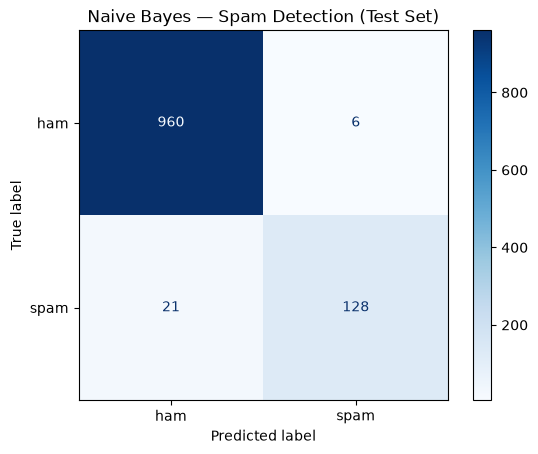

In [8]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
nb_spam = MultinomialNB()
nb_spam.fit(X_train_vec, y_train)

y_pred_spam = nb_spam.predict(X_test_vec)

spam_nb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_spam),
    'Precision': precision_score(y_test, y_pred_spam),
    'Recall': recall_score(y_test, y_pred_spam),
    'F1-score': f1_score(y_test, y_pred_spam)
}

for name, value in spam_nb_metrics.items():
    print(f"{name}: {value:.4f}")

cm_spam = confusion_matrix(y_test, y_pred_spam)
print("\nConfusion matrix:\n", cm_spam)

ConfusionMatrixDisplay(cm_spam, display_labels=['ham', 'spam']).plot(cmap='Blues')
plt.title('Naive Bayes — Spam Detection (Test Set)')
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9758 |
| Precision | 0.9552 |
| Recall | 0.8591 |
| F1-score | 0.9046 |

The confusion matrix shows 960 ham messages correctly kept, 6 ham messages wrongly flagged as spam, 21 spam messages missed, and 128 spam messages caught. Accuracy is high, but only 13% of the messages are spam, so accuracy alone is not enough. Precision is 0.9552 and recall is 0.8591, which means the model is very careful about what it calls spam but still lets some through.

**Answer 6:**
A false positive is worse here. If a real message gets flagged as spam, I might never see it, and it could be a bank code, a job message or something from family. If a spam message gets through, it is only annoying and I can delete it in a second. So if I tuned the model further I would prioritize precision, and the model already leans that way with 6 false positives against 21 false negatives.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [9]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
words = vectorizer.get_feature_names_out()

# log P(word | spam) - log P(word | ham)
log_diff = nb_spam.feature_log_prob_[1] - nb_spam.feature_log_prob_[0]

top_spam_idx = np.argsort(log_diff)[::-1][:15]
top_ham_idx = np.argsort(log_diff)[:15]

print("Top 15 spam words:")
for i in top_spam_idx:
    print(f"  {words[i]:<12} {log_diff[i]:.3f}")

print("\nTop 15 ham words:")
for i in top_ham_idx:
    print(f"  {words[i]:<12} {log_diff[i]:.3f}")

Top 15 spam words:
  claim        5.533
  prize        5.184
  won          5.057
  500          4.617
  tone         4.617
  guaranteed   4.617
  18           4.534
  1000         4.505
  150          4.380
  tcs          4.346
  150ppm       4.346
  awarded      4.311
  urgent       4.256
  collection   4.237
  award        4.198

Top 15 ham words:
  ltgt         -4.437
  ill          -4.309
  he           -3.881
  lor          -3.873
  later        -3.775
  da           -3.766
  she          -3.596
  thats        -3.415
  my           -3.317
  doing        -3.255
  say          -3.255
  really       -3.255
  ask          -3.240
  didnt        -3.240
  anything     -3.226


**Answer 7:**
Yes, the spam words match my intuition. The top ones are claim, prize, won, awarded, award, guaranteed and urgent, which are the usual "you won something" language. Numbers like 500, 1000 and 150 show up too because spam talks about money and prices. Words like 18, tcs (terms and conditions), 150ppm (price per minute) and tone (ringtones) come from the fine print and offers in these messages. The ham words are normal chat words like ill, he, she, my, later, thats and lor. The odd one is ltgt, which is a leftover from how the dataset stores the symbols "<" and ">" in some messages, so it is a quirk of the data and not a real word.

In [10]:
# Task 8 — test your own messages
my_messages = [
    "WINNER!! You have won a free prize. Call now to claim your cash reward",
    "Hey, are we still meeting at the library after class tomorrow?",
    "URGENT! Your mobile number has won a 1000 cash prize. Text CLAIM to 80086 now",
]

# apply the same cleaning that was used on the training data
cleaned_msgs = (pd.Series(my_messages)
                .str.lower()
                .str.replace(r'[^a-zA-Z0-9\s]', '', regex=True))

msg_vec = vectorizer.transform(cleaned_msgs)
msg_pred = nb_spam.predict(msg_vec)
msg_prob = nb_spam.predict_proba(msg_vec)[:, 1]

for msg, pred, prob in zip(my_messages, msg_pred, msg_prob):
    print(f"Message: {msg}")
    print(f"Prediction: {'spam' if pred == 1 else 'ham'}  (P(spam) = {prob:.4f})\n")

Message: WINNER!! You have won a free prize. Call now to claim your cash reward
Prediction: spam  (P(spam) = 1.0000)

Message: Hey, are we still meeting at the library after class tomorrow?
Prediction: ham  (P(spam) = 0.0000)

Message: URGENT! Your mobile number has won a 1000 cash prize. Text CLAIM to 80086 now
Prediction: spam  (P(spam) = 1.0000)



**Answer 8:**
All three predictions matched what I expected. The two spam-like messages were predicted as spam with P(spam) of 1.0000 because they contain words like won, prize, claim, cash and urgent. The normal message about meeting at the library was predicted as ham with P(spam) of 0.0000 because it has no spam words. These were very obvious examples, so an easy result is not surprising.

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
_[(Kaggle Notebook URL)](https://www.kaggle.com/code/haseebsamo66737/notebook00c992a05f)_

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [11]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
import re

# encode the label: negative = 0, positive = 1
tweets_df['label'] = tweets_df['airline_sentiment'].map({'negative': 0, 'positive': 1})

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)   # remove links
    text = re.sub(r'@\w+', ' ', text)              # remove @mentions
    text = text.replace('#', '')                    # keep the hashtag word, drop the #
    text = text.replace("'", '')                    # dont, isnt, cant (same as Task A)
    text = re.sub(r'[^a-z\s]', ' ', text)          # remove punctuation, digits, emojis
    return ' '.join(text.split())

tweets_df['clean_text'] = tweets_df['text'].apply(clean_tweet)
print(tweets_df[['text', 'clean_text']].head())

Xb = tweets_df['clean_text']
yb = tweets_df['label']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=42, stratify=yb
)

vectorizer_b = CountVectorizer()
Xb_train_vec = vectorizer_b.fit_transform(Xb_train)   # fit on train only
Xb_test_vec = vectorizer_b.transform(Xb_test)

print("\nVocabulary size:", len(vectorizer_b.get_feature_names_out()))
print("Training data shape:", Xb_train_vec.shape)
print("Testing data shape:", Xb_test_vec.shape)

                                                text  \
1  @VirginAmerica plus you've added commercials t...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   
5  @VirginAmerica seriously would pay $30 a fligh...   
6  @VirginAmerica yes, nearly every time I fly VX...   

                                          clean_text  
1  plus youve added commercials to the experience...  
3  its really aggressive to blast obnoxious enter...  
4            and its a really big bad thing about it  
5  seriously would pay a flight for seats that di...  
6  yes nearly every time i fly vx this ear worm w...  

Vocabulary size: 8813
Training data shape: (9232, 8813)
Testing data shape: (2309, 8813)


**Task 11 (result):** After cleaning, the vectorizer learned 8,813 words from the 9,232 training tweets. The test set has 2,309 tweets. I used CountVectorizer since it is the standard input for MultinomialNB.

**Answer 12:**
Tweets have things SMS messages did not, so I removed links and @mentions. The @mention is usually just the airline name, which is in almost every tweet and says nothing about how the customer feels, and links carry no sentiment. I also kept the hashtag word but dropped the # symbol, and I removed apostrophes so "don't" becomes "dont", the same way as in Task A.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy: 0.9065
Precision: 0.8930
Recall: 0.6173
F1-score: 0.7300

Confusion matrix:
 [[1801   35]
 [ 181  292]]


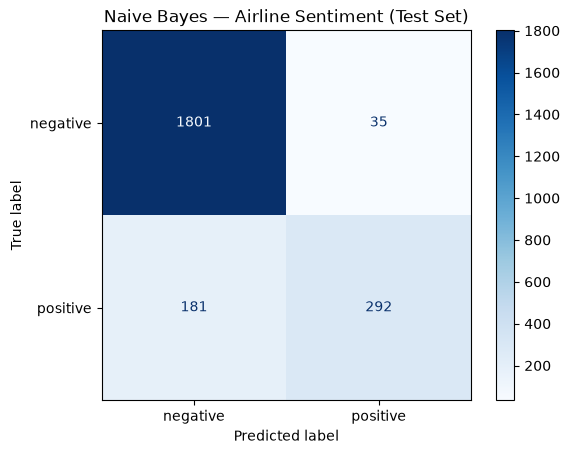

In [12]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
nb_tweet = MultinomialNB()
nb_tweet.fit(Xb_train_vec, yb_train)

yb_pred = nb_tweet.predict(Xb_test_vec)

tweet_nb_metrics = {
    'Accuracy': accuracy_score(yb_test, yb_pred),
    'Precision': precision_score(yb_test, yb_pred),
    'Recall': recall_score(yb_test, yb_pred),
    'F1-score': f1_score(yb_test, yb_pred)
}

for name, value in tweet_nb_metrics.items():
    print(f"{name}: {value:.4f}")

cm_tweet = confusion_matrix(yb_test, yb_pred)
print("\nConfusion matrix:\n", cm_tweet)

ConfusionMatrixDisplay(cm_tweet, display_labels=['negative', 'positive']).plot(cmap='Blues')
plt.title('Naive Bayes — Airline Sentiment (Test Set)')
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9065 |
| Precision | 0.8930 |
| Recall | 0.6173 |
| F1-score | 0.7300 |

The confusion matrix shows 1,801 negative tweets correctly found, 35 negative tweets wrongly called positive, 181 positive tweets missed, and 292 positive tweets caught. Accuracy looks good at 0.9065, but 80% of the tweets are negative, so it hides the weak part. Recall for positive tweets is only 0.6173, so the model misses about 4 out of every 10 positive tweets.

**Answer 14:**
Naive Bayes did worse on sentiment than on spam. Accuracy dropped from 0.9758 to 0.9065 and F1 dropped from 0.9046 to 0.7300, mostly because recall fell from 0.8591 to 0.6173. The independence assumption works well for spam because spam is formulaic, and single words like claim, prize or won are strong signals on their own. In tweets, meaning depends on context, negation and mixed opinions, so treating every word as independent is less reasonable. For example, a tweet that complains about a long wait and then thanks the rep still has many negative words, so the model calls it negative.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
_[(Kaggle Notebook URL)](https://www.kaggle.com/code/haseebsamo66737/notebook38087c586e)_

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

In [13]:
# Task 17 — compare Naive Bayes on Task A vs. Task B
comparison_tasks = pd.DataFrame({
    'Task A (Spam)': spam_nb_metrics,
    'Task B (Sentiment)': tweet_nb_metrics
}).round(4)
print(comparison_tasks)

           Task A (Spam)  Task B (Sentiment)
Accuracy          0.9758              0.9065
Precision         0.9552              0.8930
Recall            0.8591              0.6173
F1-score          0.9046              0.7300


**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9758 | 0.9065 |
| Precision | 0.9552 | 0.8930 |
| Recall | 0.8591 | 0.6173 |
| F1-score | 0.9046 | 0.7300 |

Naive Bayes is better on spam for every metric. Precision only drops a little (0.9552 to 0.8930), but recall drops a lot (0.8591 to 0.6173), so sentiment is the harder task mostly because positive tweets get missed.

In [14]:
# Task 18 — train Logistic Regression on Task A's vectorized features
lr_spam = LogisticRegression(max_iter=1000)
lr_spam.fit(X_train_vec, y_train)

y_pred_lr = lr_spam.predict(X_test_vec)

lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-score': f1_score(y_test, y_pred_lr)
}

comparison_lr = pd.DataFrame({
    'Naive Bayes': spam_nb_metrics,
    'Logistic Regression': lr_metrics
}).round(4)
print(comparison_lr)

print("\nLogistic Regression confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

           Naive Bayes  Logistic Regression
Accuracy        0.9758               0.9821
Precision       0.9552               0.9850
Recall          0.8591               0.8792
F1-score        0.9046               0.9291

Logistic Regression confusion matrix:
 [[964   2]
 [ 18 131]]


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9758 | 0.9821 |
| Precision | 0.9552 | 0.9850 |
| Recall | 0.8591 | 0.8792 |
| F1-score | 0.9046 | 0.9291 |

**Answer 18 (which wins, and does it match expectations):**
Logistic Regression wins on all four metrics. It made 2 false positives and 18 false negatives, while Naive Bayes made 6 and 21. This is what I expected, because Naive Bayes treats every word as independent, while Logistic Regression learns all the word weights together and can handle words that appear together, like "call", "free" and "txt". The gap is small though, since spam wording is very formulaic and the independence assumption does not hurt much here.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
Naive Bayes suited the spam task better, with 0.9758 accuracy and 0.9046 F1 compared to 0.9065 accuracy and 0.7300 F1 on tweets. Spam messages are formulaic, so single words like claim, prize and won already give a strong signal. What surprised me in the top words was that numbers like 500, 1000 and 150 and fine-print words like tcs were so strongly linked to spam, and that the top ham word ltgt was just a leftover symbol from the data. On the same spam features, Logistic Regression did a bit better than Naive Bayes on every metric (F1 of 0.9291 vs 0.9046). The gap was small, so Naive Bayes is still a solid and simple model for text. The limitation I saw is in the sentiment results, where recall was only 0.6173 and 181 positive tweets were called negative. Those tweets often mix a complaint with a thank you, and the model counts each word on its own, so it cannot tell which part the customer really means.

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/haseebsamo66737/notebook00c992a05f
- Task B: https://www.kaggle.com/code/haseebsamo66737/notebook38087c586e

---

## Submission Checklist

Before submitting, confirm you have:

- [X] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [X] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [X] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [X] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [X] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [X] Section 5 — Task A Kaggle Notebook published and linked
- [X] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [X] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [X] Section 8 — Task B Kaggle Notebook published and linked
- [X] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [X] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [X] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted